In [1]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [2]:
df = pd.read_csv("final_dataset.csv")

df.shape

(36457, 20)

In [3]:
df['OCCUPATION_TYPE'] = df['OCCUPATION_TYPE'].fillna('Unknown')

df = df.drop(columns=['ID', 'MAX_DELAY'])

df = pd.get_dummies(df, drop_first=True)

In [4]:
X = df.drop('TARGET', axis=1)
y = df['TARGET']

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [6]:
X_train.shape
X_test.shape

(7292, 47)

In [7]:
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

y_pred = log_model.predict(X_test)

In [8]:
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9831321996708722

Confusion Matrix:
[[7169    0]
 [ 123    0]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      7169
           1       0.00      0.00      0.00       123

    accuracy                           0.98      7292
   macro avg       0.49      0.50      0.50      7292
weighted avg       0.97      0.98      0.97      7292



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [9]:
class_weight='balanced'

In [10]:
log_model_balanced = LogisticRegression(max_iter=1000, class_weight='balanced')

log_model_balanced.fit(X_train, y_train)

y_pred_balanced = log_model_balanced.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [11]:
print("Accuracy:", accuracy_score(y_test, y_pred_balanced))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_balanced))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_balanced))

Accuracy: 0.597641250685683

Confusion Matrix:
[[4296 2873]
 [  61   62]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.60      0.75      7169
           1       0.02      0.50      0.04       123

    accuracy                           0.60      7292
   macro avg       0.50      0.55      0.39      7292
weighted avg       0.97      0.60      0.73      7292



In [12]:
tree_model = DecisionTreeClassifier(max_depth=6, random_state=42)

tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)

In [13]:
print("Accuracy:", accuracy_score(y_test, y_pred_tree))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_tree))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_tree))

Accuracy: 0.9825836533187055

Confusion Matrix:
[[7165    4]
 [ 123    0]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      7169
           1       0.00      0.00      0.00       123

    accuracy                           0.98      7292
   macro avg       0.49      0.50      0.50      7292
weighted avg       0.97      0.98      0.97      7292



In [14]:
from sklearn.ensemble import RandomForestClassifier

In [15]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [16]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.9809380142622052

Confusion Matrix:
[[7135   34]
 [ 105   18]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      7169
           1       0.35      0.15      0.21       123

    accuracy                           0.98      7292
   macro avg       0.67      0.57      0.60      7292
weighted avg       0.97      0.98      0.98      7292



In [17]:
rf_balanced = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)

rf_balanced.fit(X_train, y_train)

y_pred_rf_bal = rf_balanced.predict(X_test)

In [18]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf_bal))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf_bal))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf_bal))

Accuracy: 0.9624245748765771

Confusion Matrix:
[[6971  198]
 [  76   47]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      7169
           1       0.19      0.38      0.26       123

    accuracy                           0.96      7292
   macro avg       0.59      0.68      0.62      7292
weighted avg       0.98      0.96      0.97      7292



In [19]:
import joblib

joblib.dump(rf_balanced, "credit_approval_model.pkl")

['credit_approval_model.pkl']

In [20]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Balanced Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Balanced Random Forest"
    ],

    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_balanced),
        accuracy_score(y_test, y_pred_tree),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_rf_bal)
    ]
})

results

,Model,Accuracy
0,Logistic Regression,0.983132
1,Balanced Logistic Regression,0.597641
2,Decision Tree,0.982584
3,Random Forest,0.980938
4,Balanced Random Forest,0.962425


In [21]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.Series(
    rf_balanced.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feature_importance.head(10)

,0
DAYS_BIRTH,0.203789
AMT_INCOME_TOTAL,0.154129
DAYS_EMPLOYED,0.147410
CNT_FAM_MEMBERS,0.040461
FLAG_OWN_CAR_Y,0.030961
CNT_CHILDREN,0.029375
FLAG_PHONE,0.027378
FLAG_OWN_REALTY_Y,0.027083
NAME_INCOME_TYPE_Working,0.024369
CODE_GENDER_M,0.022391


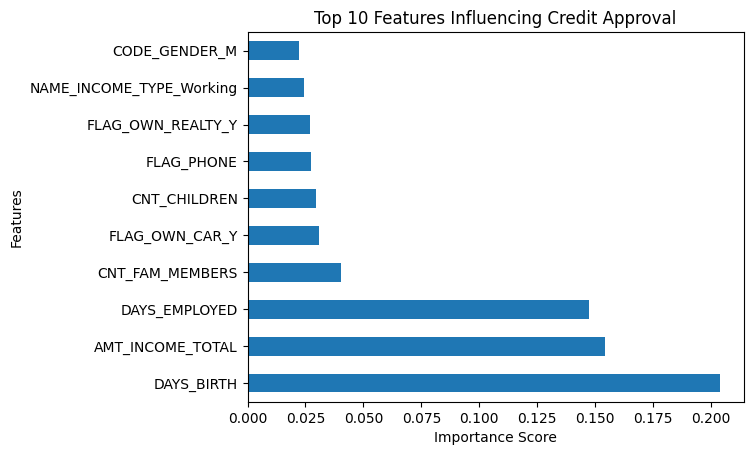

In [23]:
feature_importance.head(10).plot(kind='barh')

plt.title("Top 10 Features Influencing Credit Approval")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.show()

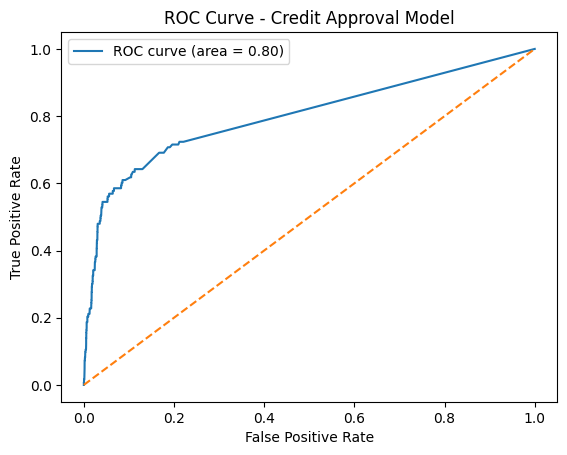

In [24]:
from sklearn.metrics import roc_curve, auc

y_prob = rf_balanced.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label="ROC curve (area = %0.2f)" % roc_auc)
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Credit Approval Model")

plt.legend()
plt.show()

In [25]:
import joblib

joblib.dump(X.columns, "model_features.pkl")

['model_features.pkl']